# Day 6.2: Addressing Overfitting & Complexity Control

## Table of Contents
- [Introduction](#introduction)
- [Recognizing Overfitting in Decision Trees](#recognizing-overfitting-in-decision-trees)
  - [Why Trees are Prone to Overfitting](#why-trees-are-prone-to-overfitting)
  - [Symptoms of Overfitting](#symptoms-of-overfitting)
  - [Visualizing Overfitting in Trees](#visualizing-overfitting-in-trees)
- [Complexity Control Techniques](#complexity-control-techniques)
  - [Pre-pruning (Early Stopping)](#pre-pruning-early-stopping)
  - [Post-pruning](#post-pruning)
  - [Key Hyperparameters in Scikit-learn](#key-hyperparameters-in-scikit-learn)
  - [Finding Optimal Hyperparameters](#finding-optimal-hyperparameters)
- [Model Interpretability](#model-interpretability)
  - ["White-Box" Models](#white-box-models)
  - [Feature Importance Calculation](#feature-importance-calculation)
  - [Benefits and Limitations of Feature Importance](#benefits-and-limitations-of-feature-importance)
- [Common Pitfalls When Using Decision Trees](#common-pitfalls-when-using-decision-trees)
- [When to Choose Decision Trees vs. Linear Models](#when-to-choose-decision-trees-vs-linear-models)

## Introduction

In our previous notebook, we explored the basic concepts of decision trees. While decision trees are powerful and interpretable models, they have a critical weakness: they tend to overfit the training data. In this notebook, we'll dive deep into this challenge and learn techniques to address it.

In [2]:
# Import libraries we'll use throughout this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler

### Key Hyperparameters in Scikit-learn

Here are the key hyperparameters in scikit-learn for controlling tree complexity:

| Hyperparameter | Description | Effect on Overfitting |
|----------------|-------------|------------------------|
| `max_depth` | Maximum depth of the tree | Directly limits tree complexity |
| `min_samples_split` | Minimum samples required to split a node | Prevents splits on small samples |
| `min_samples_leaf` | Minimum samples required in a leaf node | Ensures leaves represent enough samples |
| `max_leaf_nodes` | Maximum number of leaf nodes | Limits total leaves in the tree |
| `max_features` | Number of features to consider for best split | Introduces randomness, helps generalization |
| `ccp_alpha` | Complexity parameter for cost-complexity pruning | Controls post-pruning severity |

## Recognizing Overfitting in Decision Trees

### Why Trees are Prone to Overfitting

Decision trees have a natural tendency to overfit the training data for several reasons:

1. **Unlimited Complexity**: Without constraints, trees can grow until each leaf contains just one sample, essentially "memorizing" the training data.
2. **Greedy Algorithm**: Decision trees use a greedy approach that makes locally optimal decisions at each step, which may not lead to a globally optimal tree.
3. **Sensitivity to Data Variations**: Small changes in the training data can lead to completely different tree structures.
4. **No Regularization**: Basic decision trees lack built-in regularization mechanisms.

### Symptoms of Overfitting

How can we tell if a decision tree is overfitting? Look for these signs:

1. **Performance Gap**: High accuracy on training data but significantly lower accuracy on test data
2. **Complex Tree Structure**: Very deep trees with many nodes and leaves
3. **Erratic Decision Boundaries**: Decision boundaries that follow noise rather than underlying patterns
4. **Poor Generalization**: The model performs well on the exact training examples but fails on new data

In [3]:
# Let's demonstrate overfitting using a synthetic dataset
from sklearn.datasets import make_classification

# Create a dataset with some noise
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, 
                          n_redundant=5, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train decision trees with different max_depth values
depths = [1, 3, 5, 10, 20, None]  # None means unlimited depth
train_scores = []
test_scores = []

for depth in depths:
    # Train the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, dt.predict(X_train))
    test_accuracy = accuracy_score(y_test, dt.predict(X_test))
    
    # Store results
    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)
    
    print(f"max_depth={depth}:")
    print(f"  Training accuracy: {train_accuracy:.4f}")
    print(f"  Test accuracy: {test_accuracy:.4f}")
    print(f"  Gap: {train_accuracy - test_accuracy:.4f}")
    print(f"  Tree depth: {dt.get_depth()}")
    print(f"  Number of leaves: {dt.get_n_leaves()}")
    print()

max_depth=1:
  Training accuracy: 0.8343
  Test accuracy: 0.7967
  Gap: 0.0376
  Tree depth: 1
  Number of leaves: 2

max_depth=3:
  Training accuracy: 0.9143
  Test accuracy: 0.8567
  Gap: 0.0576
  Tree depth: 3
  Number of leaves: 8

max_depth=5:
  Training accuracy: 0.9514
  Test accuracy: 0.8900
  Gap: 0.0614
  Tree depth: 5
  Number of leaves: 22

max_depth=10:
  Training accuracy: 1.0000
  Test accuracy: 0.8733
  Gap: 0.1267
  Tree depth: 9
  Number of leaves: 47

max_depth=20:
  Training accuracy: 1.0000
  Test accuracy: 0.8733
  Gap: 0.1267
  Tree depth: 9
  Number of leaves: 47

max_depth=None:
  Training accuracy: 1.0000
  Test accuracy: 0.8733
  Gap: 0.1267
  Tree depth: 9
  Number of leaves: 47



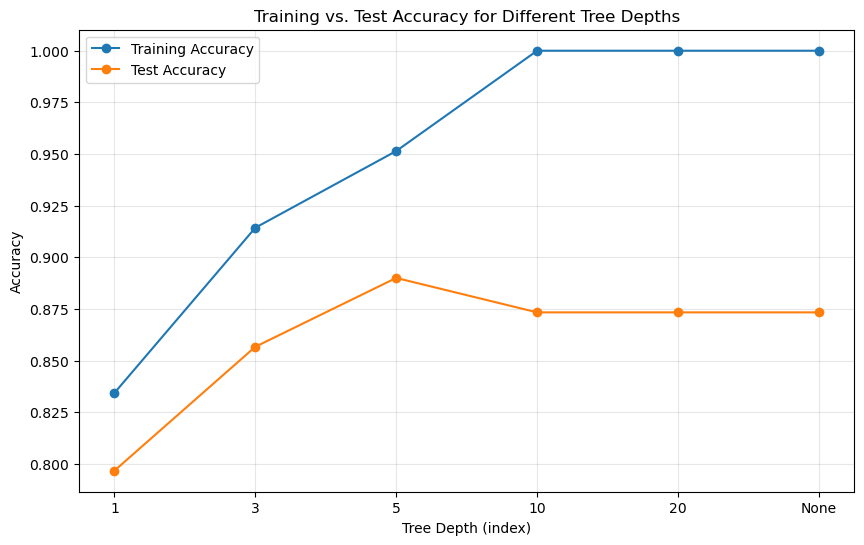

In [4]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_scores, marker='o', linestyle='-', label='Training Accuracy')
plt.plot(range(len(depths)), test_scores, marker='o', linestyle='-', label='Test Accuracy')
plt.xlabel('Tree Depth (index)')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy for Different Tree Depths')
plt.xticks(range(len(depths)), [str(d) if d is not None else 'None' for d in depths])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Visualizing Overfitting in Trees

Let's visualize overfitting by creating a simple 2D dataset and observing how trees of different depths fit the data:

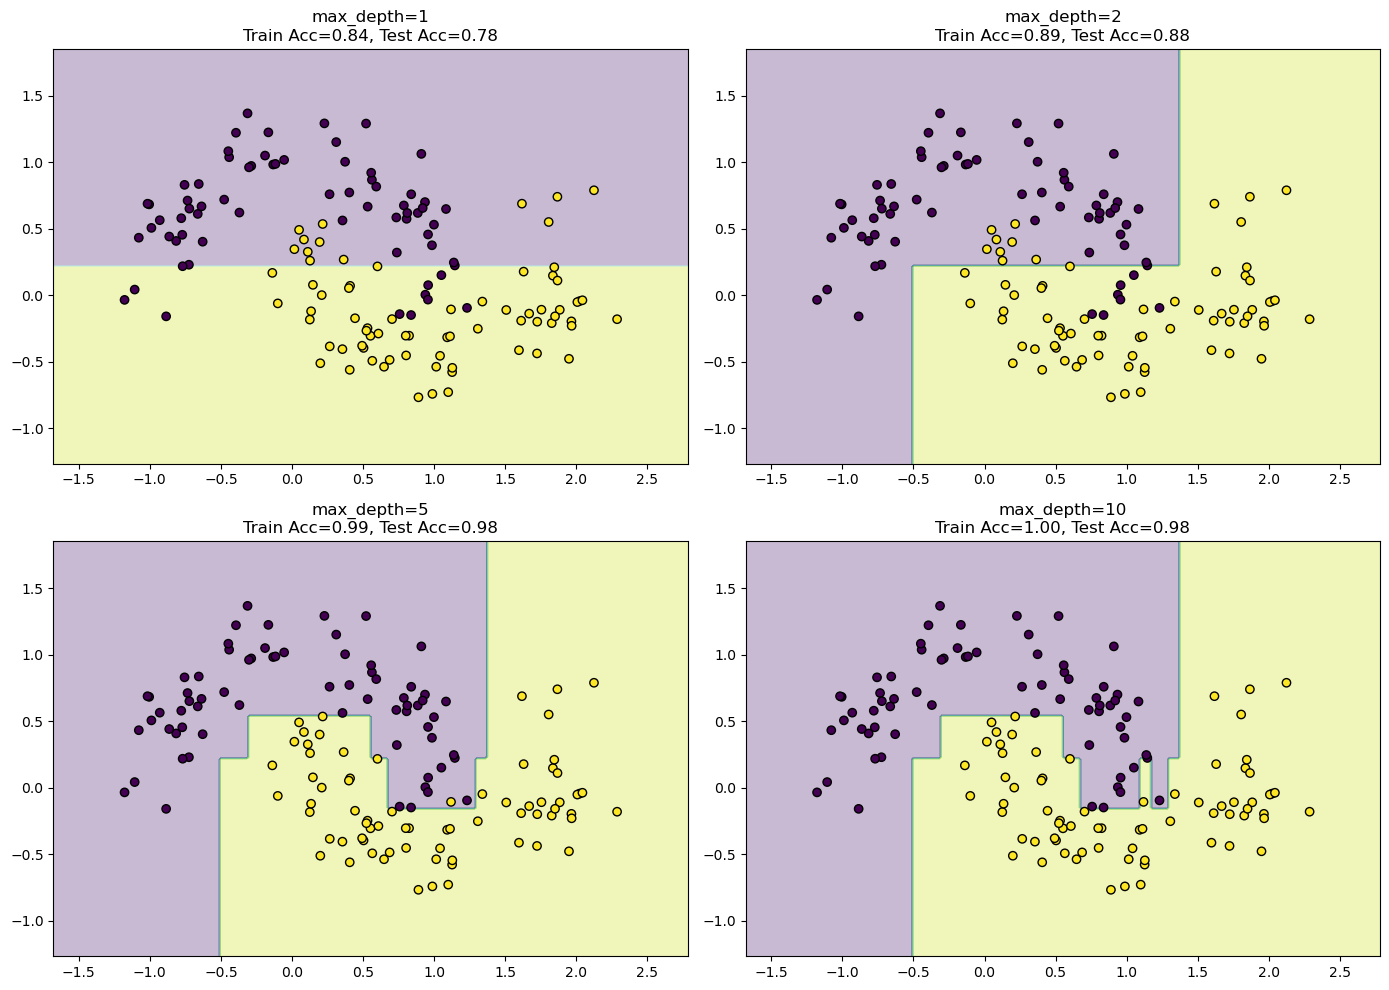

In [5]:
# Create a simple 2D dataset for visualization
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    h = 0.02  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict class for each point in mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)

# Create decision trees with different depths
depths = [1, 2, 5, 10]
plt.figure(figsize=(14, 10))

for i, depth in enumerate(depths):
    plt.subplot(2, 2, i+1)
    
    # Train the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Calculate scores
    train_score = accuracy_score(y_train, dt.predict(X_train))
    test_score = accuracy_score(y_test, dt.predict(X_test))
    
    # Plot decision boundary
    plot_decision_boundary(dt, X_train, y_train, 
                           f"max_depth={depth}\nTrain Acc={train_score:.2f}, Test Acc={test_score:.2f}")

plt.tight_layout()
plt.show()

### Knowledge Check: Recognizing Overfitting
1. What makes decision trees particularly prone to overfitting compared to other models?
2. How would you identify an overfit decision tree by looking at its performance metrics?
3. Why might a decision tree with 100% training accuracy be concerning?
4. What happens to the decision boundary as a tree becomes more complex (deeper)?
5. If you observe a training accuracy of 0.98 and a test accuracy of 0.72, what might this indicate about your model?

## Complexity Control Techniques

To combat overfitting in decision trees, we need to control their complexity. There are two main approaches: pre-pruning and post-pruning.

### Pre-pruning (Early Stopping)

Pre-pruning stops the tree from growing too deep in the first place by setting constraints before building the tree. This is the primary approach used in scikit-learn's implementation.

In [6]:
# Demonstrate pre-pruning with max_depth
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define depth range to explore
max_depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
train_scores = []
test_scores = []
tree_depths = []
leaf_counts = []

for depth in max_depths:
    # Train model with specified max_depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Get predictions
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)
    
    # Compute accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Store results
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    # Store tree structure info
    tree_depths.append(dt.get_depth())
    leaf_counts.append(dt.get_n_leaves())
    
    print(f"\nmax_depth={depth}:")
    print(f"  Training accuracy: {train_acc:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Actual tree depth: {dt.get_depth()}")
    print(f"  Number of leaves: {dt.get_n_leaves()}")


max_depth=1:
  Training accuracy: 0.9246
  Test accuracy: 0.8947
  Actual tree depth: 1
  Number of leaves: 2

max_depth=2:
  Training accuracy: 0.9422
  Test accuracy: 0.9298
  Actual tree depth: 2
  Number of leaves: 4

max_depth=3:
  Training accuracy: 0.9698
  Test accuracy: 0.9649
  Actual tree depth: 3
  Number of leaves: 8

max_depth=5:
  Training accuracy: 0.9950
  Test accuracy: 0.9532
  Actual tree depth: 5
  Number of leaves: 13

max_depth=7:
  Training accuracy: 1.0000
  Test accuracy: 0.9415
  Actual tree depth: 7
  Number of leaves: 16

max_depth=10:
  Training accuracy: 1.0000
  Test accuracy: 0.9415
  Actual tree depth: 7
  Number of leaves: 16

max_depth=15:
  Training accuracy: 1.0000
  Test accuracy: 0.9415
  Actual tree depth: 7
  Number of leaves: 16

max_depth=20:
  Training accuracy: 1.0000
  Test accuracy: 0.9415
  Actual tree depth: 7
  Number of leaves: 16

max_depth=None:
  Training accuracy: 1.0000
  Test accuracy: 0.9415
  Actual tree depth: 7
  Number of 

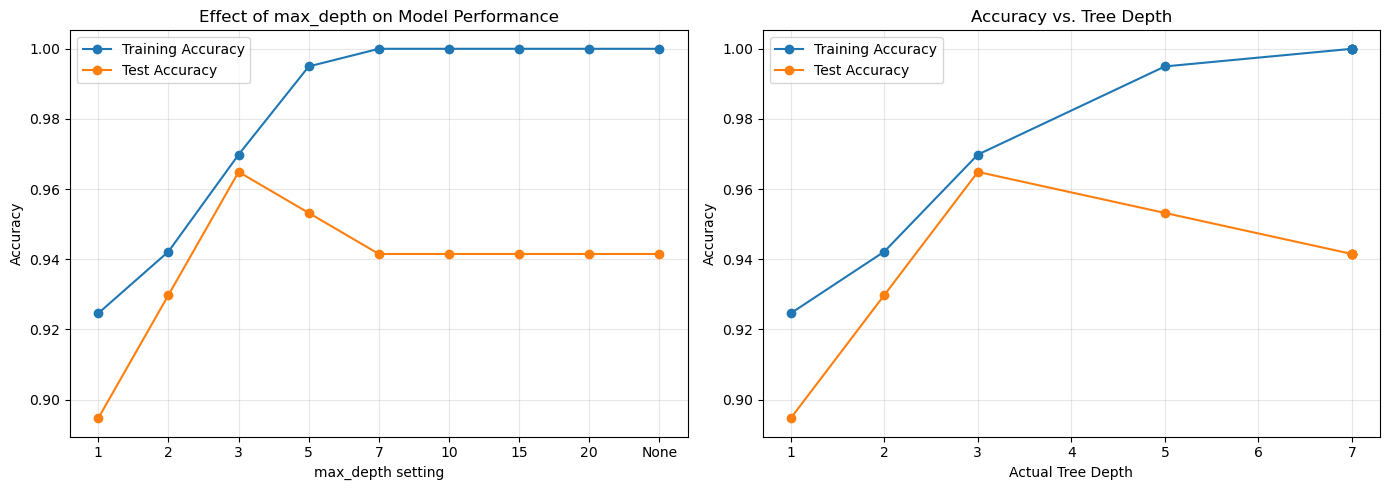

In [7]:
# Plot results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(max_depths)), train_scores, 'o-', label='Training Accuracy')
plt.plot(range(len(max_depths)), test_scores, 'o-', label='Test Accuracy')
plt.xlabel('max_depth setting')
plt.ylabel('Accuracy')
plt.xticks(range(len(max_depths)), [str(d) if d is not None else 'None' for d in max_depths])
plt.title('Effect of max_depth on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(tree_depths, train_scores, 'o-', label='Training Accuracy')
plt.plot(tree_depths, test_scores, 'o-', label='Test Accuracy')
plt.xlabel('Actual Tree Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

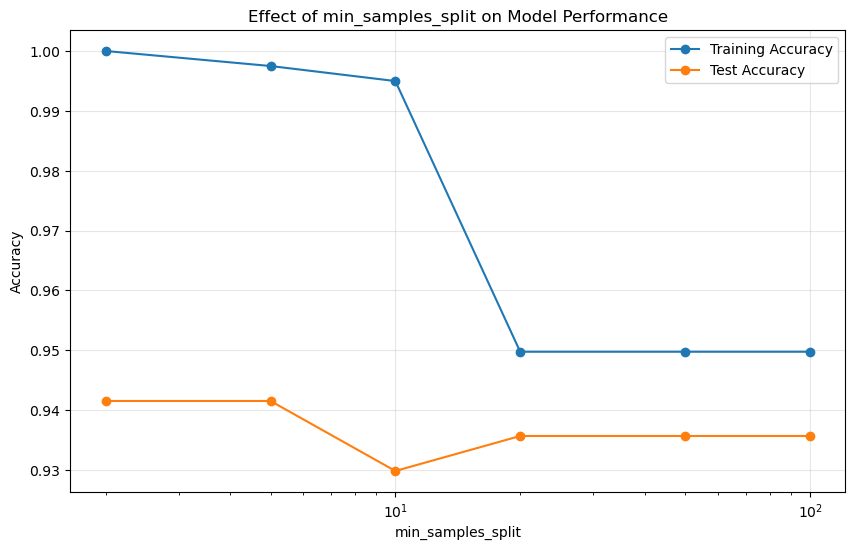

In [8]:
# Let's also explore min_samples_split parameter
min_samples_splits = [2, 5, 10, 20, 50, 100]
train_scores_mss = []
test_scores_mss = []

for min_samples in min_samples_splits:
    # Train model with specified min_samples_split
    dt = DecisionTreeClassifier(min_samples_split=min_samples, random_state=42)
    dt.fit(X_train, y_train)
    
    # Get predictions and compute accuracy
    train_scores_mss.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores_mss.append(accuracy_score(y_test, dt.predict(X_test)))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(min_samples_splits, train_scores_mss, 'o-', label='Training Accuracy')
plt.plot(min_samples_splits, test_scores_mss, 'o-', label='Test Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Effect of min_samples_split on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

### Post-pruning

Post-pruning involves building a full tree first, then pruning (removing) nodes that provide little predictive power. In scikit-learn, Cost-Complexity Pruning (CCP) is available through the `ccp_alpha` parameter.

In [9]:
# Demonstrate post-pruning with Cost-Complexity Pruning (CCP)
from sklearn.tree._tree import TREE_LEAF

# Get the path of cost-complexity pruning alphas
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the last alpha as it's often too large and results in a trivial tree
if len(ccp_alphas) > 1:
    ccp_alphas = ccp_alphas[:-1]

# Train models with different ccp_alphas
train_scores_ccp = []
test_scores_ccp = []
node_counts = []

for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)
    dt.fit(X_train, y_train)
    
    train_scores_ccp.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores_ccp.append(accuracy_score(y_test, dt.predict(X_test)))
    node_counts.append(dt.tree_.node_count)

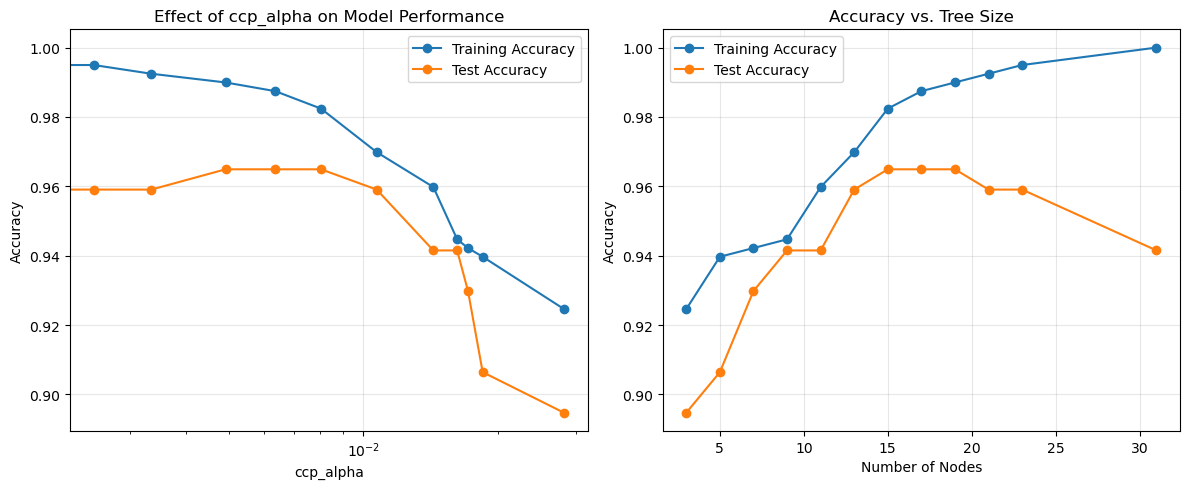

In [10]:
# Plot results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ccp_alphas, train_scores_ccp, 'o-', label='Training Accuracy')
plt.plot(ccp_alphas, test_scores_ccp, 'o-', label='Test Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Effect of ccp_alpha on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(node_counts, train_scores_ccp, 'o-', label='Training Accuracy')
plt.plot(node_counts, test_scores_ccp, 'o-', label='Test Accuracy')
plt.xlabel('Number of Nodes')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Tree Size')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Find the optimal alpha value
best_alpha_idx = np.argmax(test_scores_ccp)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Best test accuracy: {test_scores_ccp[best_alpha_idx]:.4f}")

Best ccp_alpha: 0.004915
Best test accuracy: 0.9649


In [12]:
# Train a tree with the optimal alpha
best_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_tree.fit(X_train, y_train)

print(f"Tree depth with optimal ccp_alpha: {best_tree.get_depth()}")
print(f"Number of leaves with optimal ccp_alpha: {best_tree.get_n_leaves()}")

Tree depth with optimal ccp_alpha: 4
Number of leaves with optimal ccp_alpha: 10


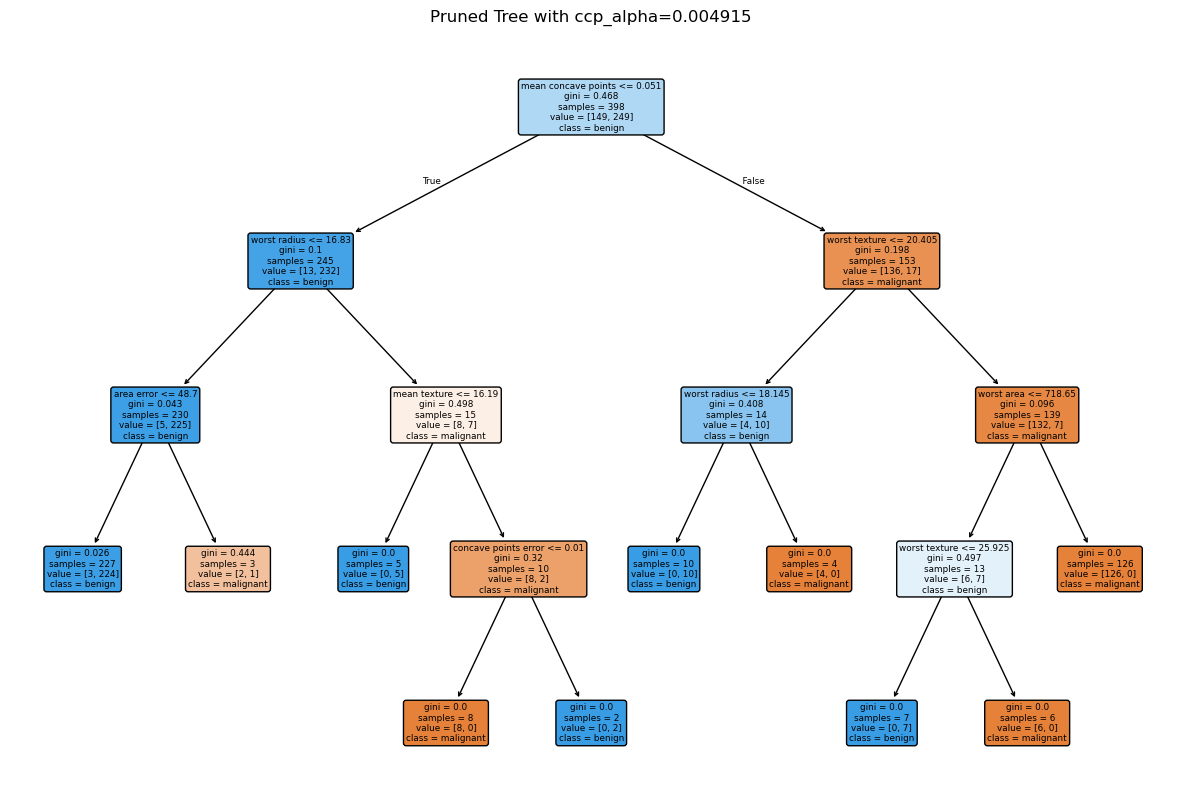

In [13]:
# Visualize the pruned tree
plt.figure(figsize=(15, 10))
plot_tree(best_tree, filled=True, feature_names=cancer.feature_names,
          class_names=['malignant', 'benign'], rounded=True)
plt.title(f"Pruned Tree with ccp_alpha={best_alpha:.6f}")
plt.show()

### Key Hyperparameters in Scikit-learn

Here are the key hyperparameters in scikit-learn for controlling tree complexity:

| Hyperparameter | Description | Effect on Overfitting |
|----------------|-------------|------------------------|
| `max_depth` | Maximum depth of the tree | Directly limits tree complexity |
| `min_samples_split` | Minimum samples required to split a node | Prevents splits on small samples |
| `min_samples_leaf` | Minimum samples required in a leaf node | Ensures leaves represent enough samples |
| `max_leaf_nodes` | Maximum number of leaf nodes | Limits total leaves in the tree |
| `max_features` | Number of features to consider for best split | Introduces randomness, helps generalization |
| `ccp_alpha` | Complexity parameter for cost-complexity pruning | Controls post-pruning severity |

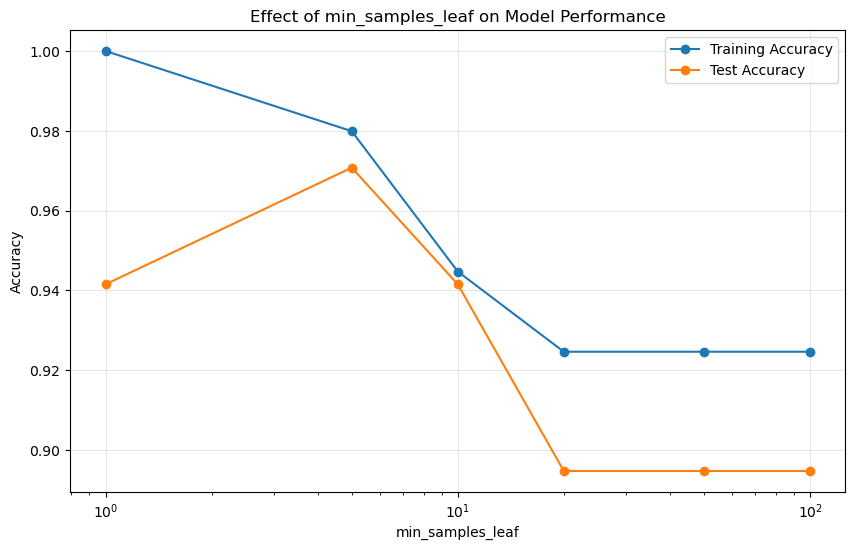

In [15]:
# Demonstrate min_samples_leaf
min_samples_leaves = [1, 5, 10, 20, 50, 100]
train_scores_msl = []
test_scores_msl = []
tree_depths_msl = []

for min_leaf in min_samples_leaves:
    dt = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42)
    dt.fit(X_train, y_train)
    
    train_scores_msl.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores_msl.append(accuracy_score(y_test, dt.predict(X_test)))
    tree_depths_msl.append(dt.get_depth())

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(min_samples_leaves, train_scores_msl, 'o-', label='Training Accuracy')
plt.plot(min_samples_leaves, test_scores_msl, 'o-', label='Test Accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.title('Effect of min_samples_leaf on Model Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

### Finding Optimal Hyperparameters

To find the best hyperparameters, we typically use techniques like cross-validation and grid search. (We'll cover these in more detail on Day 8, but here's a preview):

In [16]:
# Preview of cross-validation for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Create grid search object
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1  # Use all available cores
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.9247


In [17]:
# Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
print("Test accuracy with best model: {:.4f}".format(test_accuracy))

Test accuracy with best model: 0.9649


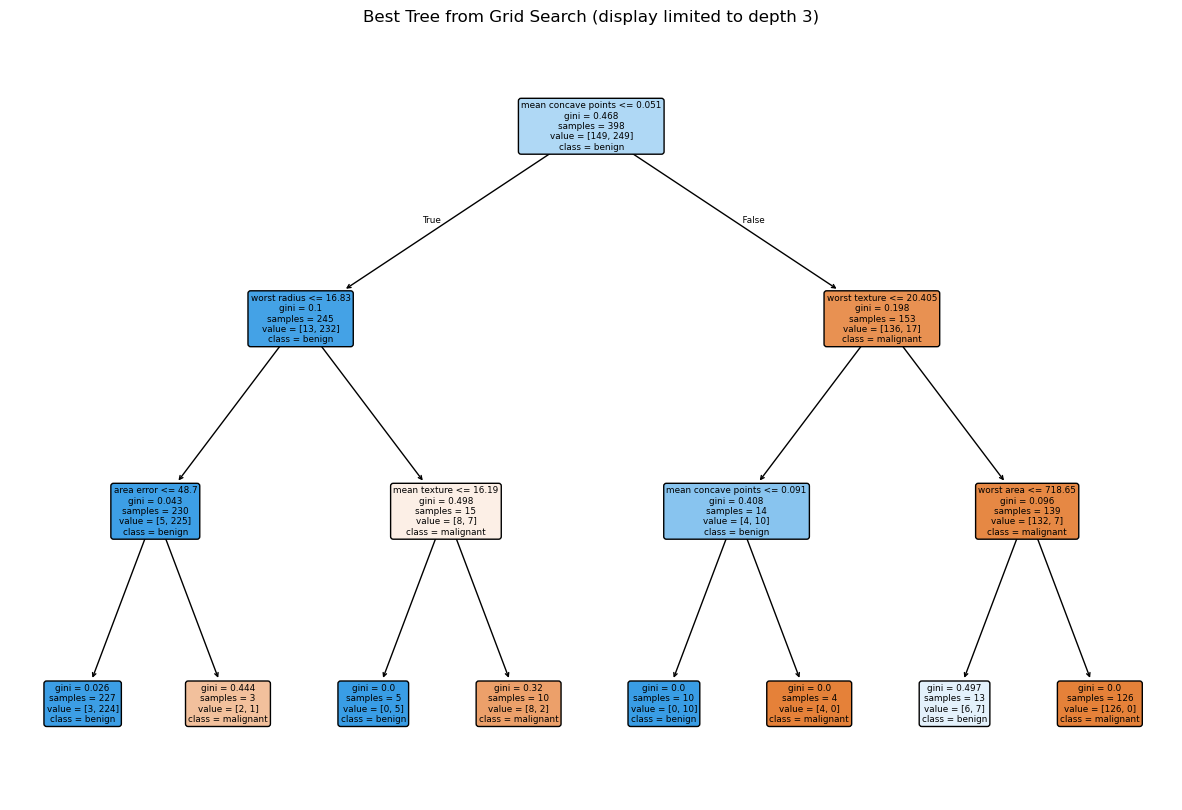

In [18]:
# Visualize the best tree
plt.figure(figsize=(15, 10))
plot_tree(best_model, filled=True, feature_names=cancer.feature_names,
          class_names=['malignant', 'benign'], rounded=True, max_depth=3)  # Limit display depth for readability
plt.title("Best Tree from Grid Search (display limited to depth 3)")
plt.show()

### Knowledge Check: Complexity Control
1. What is the difference between pre-pruning and post-pruning in decision trees?
2. How does increasing the `min_samples_split` parameter affect the risk of overfitting?
3. Which hyperparameter in scikit-learn enables cost-complexity pruning?
4. If you increase `max_features` from 1 to 10 in a dataset with 20 features, how would this likely affect model complexity?
5. When might limiting the `max_depth` be preferable to using `ccp_alpha` for pruning?

## Model Interpretability

One of the key advantages of decision trees is their interpretability, which is why they're often called "white-box" models.

### "White-Box" Models

"White-box" models are those whose internal decision-making process is transparent and understandable by humans. Unlike "black-box" models like neural networks, decision trees allow us to:

1. See exactly how predictions are made
2. Understand which features are important
3. Extract rules that can be easily communicated
4. Identify potential biases in the model's logic

In [19]:
# Extract decision rules from a trained decision tree
from sklearn.tree import export_text

# Train a simple tree with the breast cancer dataset
tree_for_rules = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_for_rules.fit(X_train, y_train)

# Extract the text representation
tree_rules = export_text(tree_for_rules, feature_names=list(cancer.feature_names))
print("Decision Rules:")
print(tree_rules)

Decision Rules:
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- mean texture <= 16.19
|   |   |   |--- class: 1
|   |   |--- mean texture >  16.19
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst texture <= 20.40
|   |   |--- mean concave points <= 0.09
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.09
|   |   |   |--- class: 0
|   |--- worst texture >  20.40
|   |   |--- worst area <= 718.65
|   |   |   |--- class: 1
|   |   |--- worst area >  718.65
|   |   |   |--- class: 0



In [20]:
# Make a prediction for a sample and show the path
def explain_prediction(tree, X, feature_names):
    n_nodes = tree.tree_.node_count
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    
    # Get the prediction
    pred = tree.predict([X])[0]
    
    # Find path to prediction
    node_id = 0  # Start at root
    path = [(node_id, "root")]
    
    while children_left[node_id] != children_right[node_id]:  # While not a leaf
        if X[feature[node_id]] <= threshold[node_id]:
            next_node = children_left[node_id]
            path.append((next_node, f"{feature_names[feature[node_id]]} <= {threshold[node_id]:.2f}"))
        else:
            next_node = children_right[node_id]
            path.append((next_node, f"{feature_names[feature[node_id]]} > {threshold[node_id]:.2f}"))
        node_id = next_node
    
    return pred, path

# Explain a prediction for the first test sample
sample = X_test[0]
prediction, path = explain_prediction(tree_for_rules, sample, cancer.feature_names)
print(f"\nPrediction for sample: {'Benign' if prediction == 1 else 'Malignant'}")
print("Decision path:")
for node, decision in path:
    print(f"  Node {node}: {decision}")


Prediction for sample: Benign
Decision path:
  Node 0: root
  Node 1: mean concave points <= 0.05
  Node 2: worst radius <= 16.83
  Node 3: area error <= 48.70


### Feature Importance Calculation

Decision trees provide a measure of "feature importance" that indicates how useful each feature was for making predictions:

In [ ]:
# Calculate and visualize feature importances
importances = tree_for_rules.feature_importances_
indices = np.argsort(importances)[::-1]

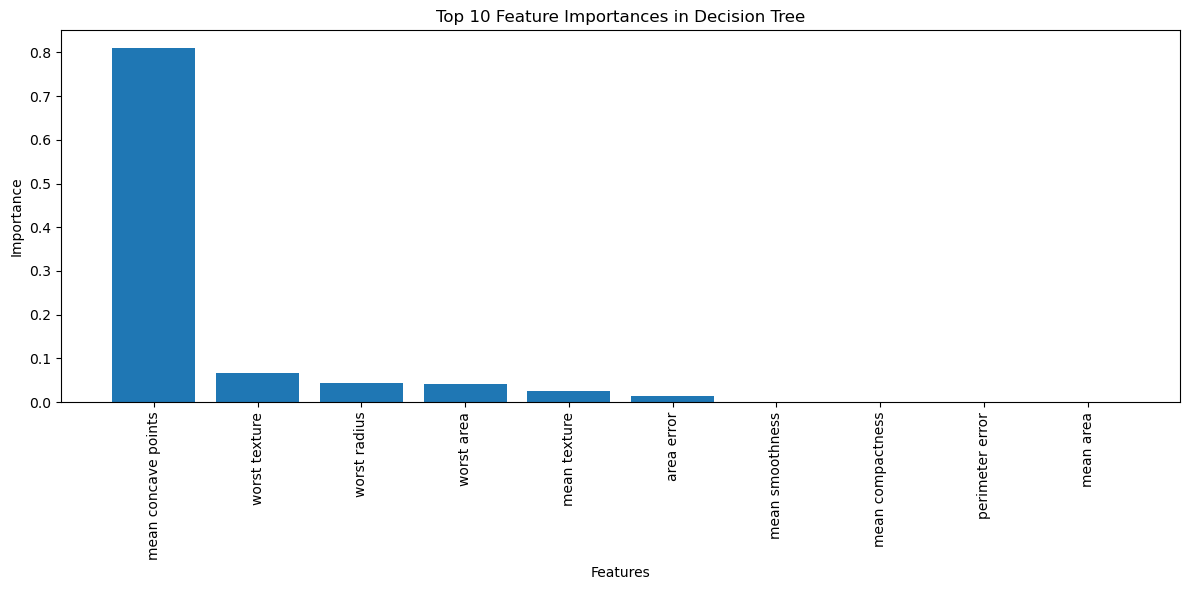

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(indices[:10])), importances[indices[:10]], align='center')
plt.xticks(range(len(indices[:10])), [cancer.feature_names[i] for i in indices[:10]], rotation=90)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances in Decision Tree')
plt.tight_layout()
plt.show()

In [22]:
# Feature importance in tabular form
feature_importance_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("Feature Importances (top 10):")
print(feature_importance_df.head(10))

Feature Importances (top 10):
                 Feature  Importance
7    mean concave points    0.809978
21         worst texture    0.066145
20          worst radius    0.043482
23            worst area    0.040310
1           mean texture    0.025169
13            area error    0.014916
0            mean radius    0.000000
17  concave points error    0.000000
28        worst symmetry    0.000000
27  worst concave points    0.000000


### How Feature Importance is Calculated

In scikit-learn, feature importance is calculated based on how much each feature contributes to reducing impurity (Gini or Entropy) across all nodes where it's used:

1. For each feature used in the tree, sum the weighted impurity decreases for all nodes where the feature was used for splitting
2. Normalize these sums so they add up to 1.0

Mathematically, for a node $m$, the importance of feature $j$ used for splitting is:

$$n_m \cdot \Delta i(m)$$

Where:
- $n_m$ is the number of samples reaching node $m$
- $\Delta i(m)$ is the impurity decrease at node $m$

The decrease in impurity is:

$$\Delta i(m) = i(m) - \frac{n_{left}}{n_m}i(m_{left}) - \frac{n_{right}}{n_m}i(m_{right})$$

Where:
- $i(m)$ is the impurity of node $m$
- $i(m_{left})$ and $i(m_{right})$ are the impurities of the left and right child nodes
- $n_{left}$ and $n_{right}$ are the numbers of samples in the left and right child nodes

### Benefits and Limitations of Feature Importance

**Benefits:**
- Provides insight into which features drive the model's decisions
- Can be used for feature selection
- Helps in explaining the model to stakeholders

**Limitations:**
- Unstable in single trees (varies with small data changes)
- Correlated features can share importance (one might get high score, the other low)
- Biased toward high-cardinality features (those with many possible values)

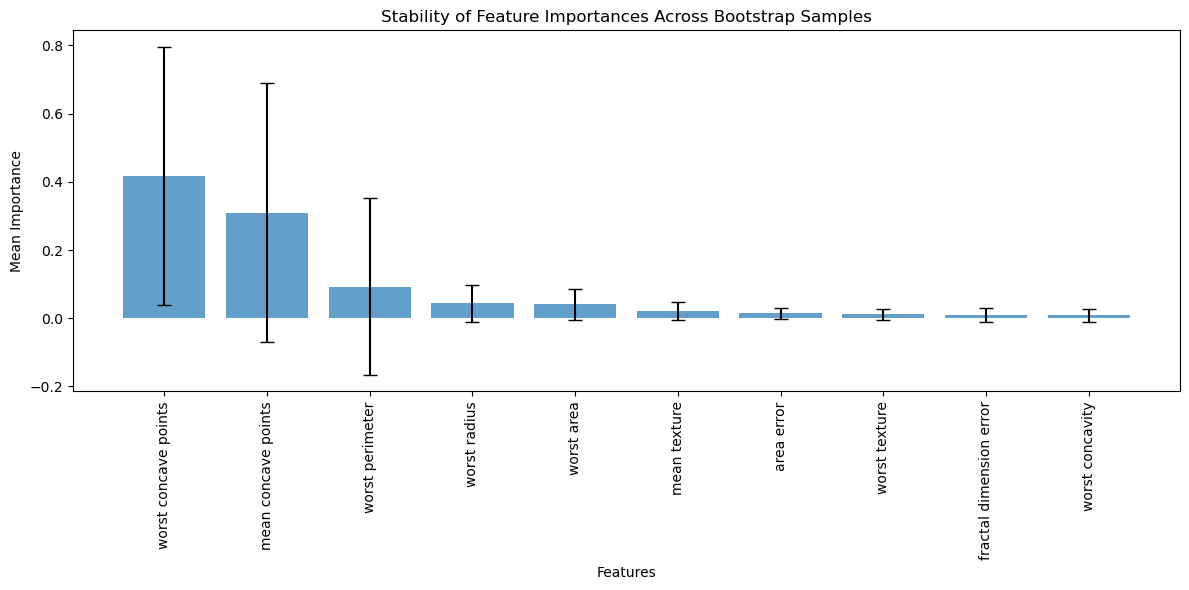

In [23]:
# Demonstrate instability of feature importance with small data changes
from sklearn.utils import resample

n_iterations = 10
all_importances = np.zeros((n_iterations, len(cancer.feature_names)))

for i in range(n_iterations):
    # Create bootstrap sample
    X_bootstrap, y_bootstrap = resample(X_train, y_train, random_state=i)
    
    # Train a tree
    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt.fit(X_bootstrap, y_bootstrap)
    
    # Store feature importances
    all_importances[i] = dt.feature_importances_

# Calculate mean and standard deviation
mean_importances = np.mean(all_importances, axis=0)
std_importances = np.std(all_importances, axis=0)

# Sort by mean importance
indices = np.argsort(mean_importances)[::-1]
top_indices = indices[:10]

# Plot mean and variation
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_indices)), mean_importances[top_indices], yerr=std_importances[top_indices],
        align='center', alpha=0.7, ecolor='black', capsize=5)
plt.xticks(range(len(top_indices)), [cancer.feature_names[i] for i in top_indices], rotation=90)
plt.xlabel('Features')
plt.ylabel('Mean Importance')
plt.title('Stability of Feature Importances Across Bootstrap Samples')
plt.tight_layout()
plt.show()

### Knowledge Check: Model Interpretability
1. What makes decision trees "white-box" models compared to other algorithms like neural networks?
2. How is feature importance calculated in scikit-learn's decision trees?
3. Why might feature importance be unstable in a single decision tree?
4. How would you use feature importance in a real-world machine learning project?
5. What are some limitations of using feature importance for feature selection?

## Common Pitfalls When Using Decision Trees

Although decision trees are intuitive and powerful, there are several common pitfalls to be aware of:

1. **Overfitting**: As we've discussed, decision trees easily overfit without proper pruning.

2. **Instability**: Small changes in data can lead to completely different trees.

3. **Axis-Parallel Splits**: Trees can only make splits perpendicular to feature axes, making them inefficient for some relationships.

4. **Bias Toward High-Cardinality Features**: Trees tend to favor features with many unique values.

5. **Poor Performance on Unbalanced Data**: Trees may focus on the majority class.

6. **No Native Support for Missing Values**: scikit-learn's implementation requires complete data.

7. **Lack of Smoothness**: Predictions change abruptly at decision boundaries.

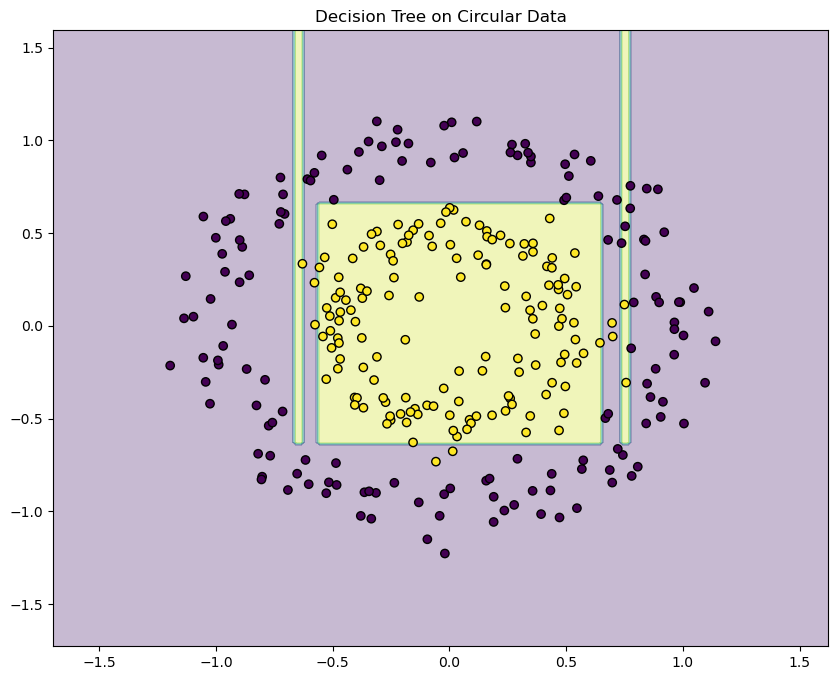

In [24]:
# Demonstration of axis-parallel splits limitation
from sklearn.datasets import make_circles

# Create a circular dataset
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)

# Train a decision tree
dt_circles = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_circles.fit(X_train_c, y_train_c)

# Plot decision boundary
plt.figure(figsize=(10, 8))
plot_decision_boundary(dt_circles, X_circles, y_circles, "Decision Tree on Circular Data")
plt.show()

In [25]:
# Calculate train and test accuracy
train_acc_c = accuracy_score(y_train_c, dt_circles.predict(X_train_c))
test_acc_c = accuracy_score(y_test_c, dt_circles.predict(X_test_c))
print(f"Training accuracy on circular data: {train_acc_c:.4f}")
print(f"Test accuracy on circular data: {test_acc_c:.4f}")

Training accuracy on circular data: 0.9952
Test accuracy on circular data: 0.9444


**Handling These Pitfalls:**

1. **Overfitting**: Use pruning techniques (max_depth, min_samples_leaf, etc.)
2. **Instability**: Use ensemble methods like Random Forests (Day 7)
3. **Axis-Parallel Splits**: Consider feature engineering or different algorithms
4. **Bias Issues**: Balance datasets and use appropriate evaluation metrics
5. **Missing Values**: Impute missing values before training
6. **Lack of Smoothness**: Use ensemble methods for smoother predictions

### Knowledge Check: Common Pitfalls
1. Why do decision trees struggle with circular or diagonal decision boundaries?
2. What can you do if your decision tree is giving unstable results on different train-test splits?
3. How might you handle missing values when using decision trees?
4. Why might a decision tree perform poorly on an imbalanced dataset, and how would you address this?
5. What types of feature engineering might help improve decision tree performance?

## When to Choose Decision Trees vs. Linear Models

When should you use decision trees, and when are linear models better?

**Decision Trees Are Better When:**

1. **Non-linear Relationships**: The relationship between features and the target is complex
2. **Feature Interaction**: Features interact in ways that are difficult to model explicitly
3. **Interpretability**: You need to explain the model's decisions in simple terms
4. **Mixed Data Types**: You have both categorical and numerical features
5. **No Preprocessing**: You want to avoid extensive feature scaling or transformation

**Linear Models Are Better When:**

1. **Linear Relationships**: The relationship between features and target is linear
2. **Extrapolation**: You need to make predictions outside the range of training data
3. **Small Dataset**: You have limited training data
4. **Stable Predictions**: You want smoother decision boundaries
5. **Regularization**: You need built-in mechanisms to prevent overfitting

In [27]:
# Compare decision tree and linear model on different datasets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Function to evaluate models
def compare_models(X, y, title):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Scale for logistic regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train models
    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    lr = LogisticRegression(random_state=42, max_iter=1000)
    
    dt.fit(X_train, y_train)
    lr.fit(X_train_scaled, y_train)
    
    # Evaluate
    dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
    dt_test_acc = accuracy_score(y_test, dt.predict(X_test))
    lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
    lr_test_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
    
    print(f"\n--- {title} ---")
    print(f"Decision Tree - Train Accuracy: {dt_train_acc:.4f}, Test Accuracy: {dt_test_acc:.4f}")
    print(f"Logistic Regression - Train Accuracy: {lr_train_acc:.4f}, Test Accuracy: {lr_test_acc:.4f}")
    
    # Plot decision boundaries if 2D
    if X.shape[1] == 2:
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plot_decision_boundary(dt, X, y, "Decision Tree")
        
        plt.subplot(1, 2, 2)
        plot_decision_boundary(lr, X, y, "Logistic Regression")
        
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()

# Linear dataset
X_linear, y_linear = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2,
                                         n_clusters_per_class=1, random_state=42)
# Circular dataset (already created above)

# Non-linear dataset (moons)
X_nonlinear, y_nonlinear = make_moons(n_samples=500, noise=0.1, random_state=42)


--- Linear Data (Linearly Separable) ---
Decision Tree - Train Accuracy: 0.9657, Test Accuracy: 0.9533
Logistic Regression - Train Accuracy: 0.8914, Test Accuracy: 0.8467


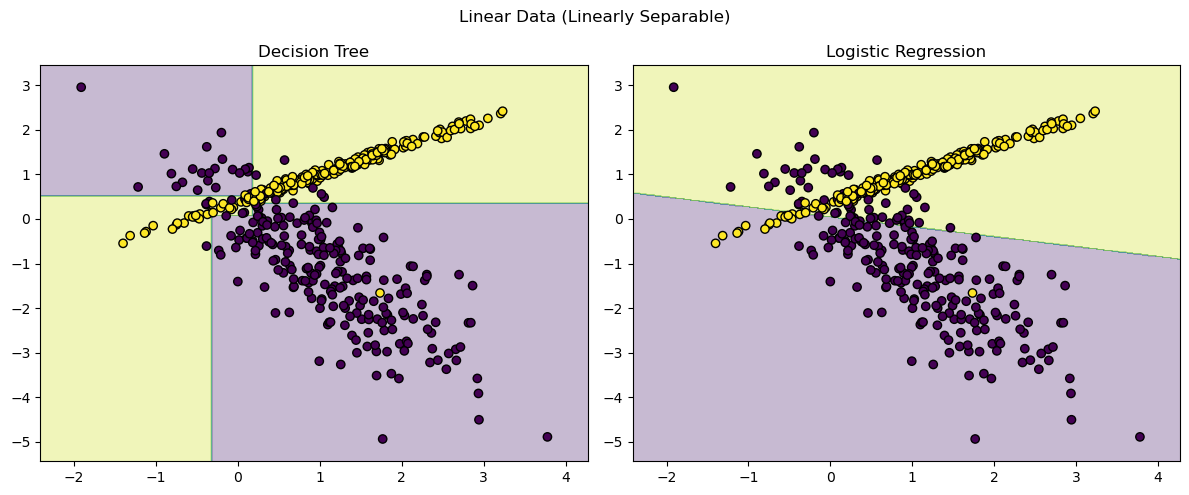

In [28]:
# Compare on each dataset
compare_models(X_linear, y_linear, "Linear Data (Linearly Separable)")


--- Circular Data (Non-linearly Separable) ---
Decision Tree - Train Accuracy: 0.8905, Test Accuracy: 0.8111
Logistic Regression - Train Accuracy: 0.4381, Test Accuracy: 0.2889


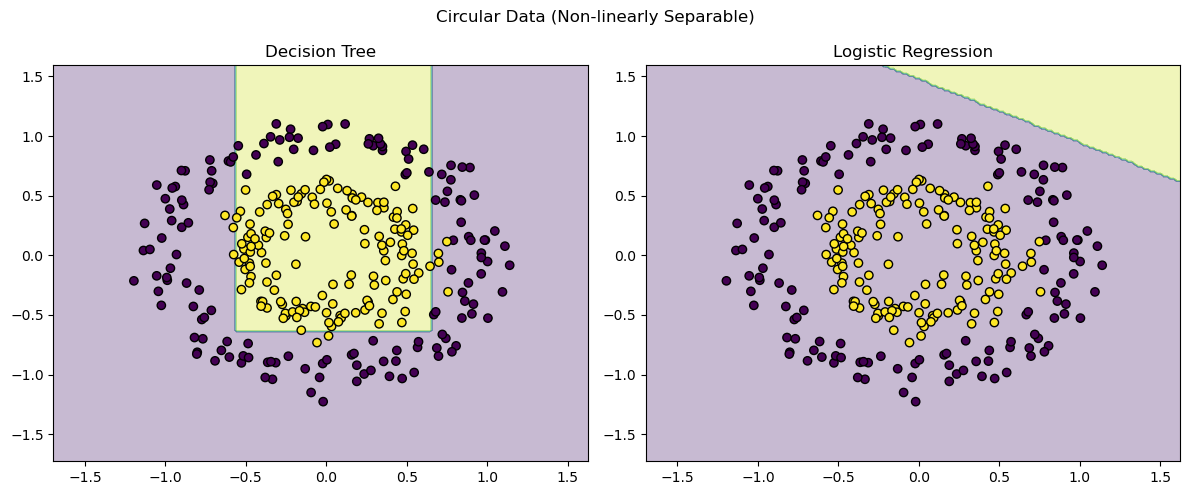

In [29]:
compare_models(X_circles, y_circles, "Circular Data (Non-linearly Separable)")


--- Moon Data (Non-linearly Separable) ---
Decision Tree - Train Accuracy: 0.9229, Test Accuracy: 0.9200
Logistic Regression - Train Accuracy: 0.8743, Test Accuracy: 0.8800


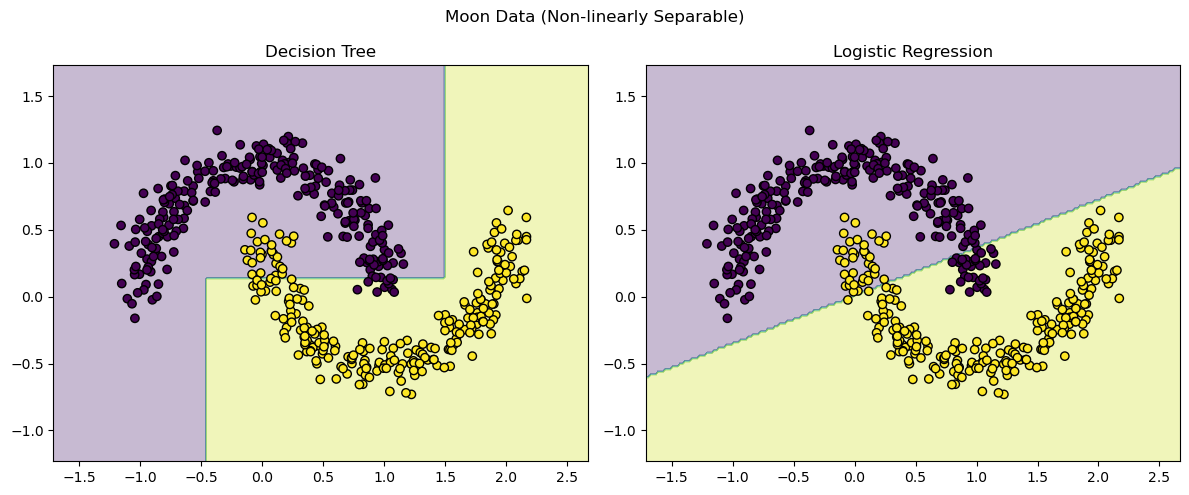

In [30]:
compare_models(X_nonlinear, y_nonlinear, "Moon Data (Non-linearly Separable)")

### Knowledge Check: Model Selection
1. For what types of problems would you recommend decision trees over linear models?
2. When would you prefer to use a linear model despite its limitations?
3. How does the amount of available training data affect your choice between decision trees and linear models?
4. If you need to make predictions outside the range of your training data, which model type would be better, and why?
5. What preprocessing steps are typically required for decision trees versus linear models?

## Conclusion

In this notebook, we've explored the critical challenge of overfitting in decision trees and learned various techniques to control complexity:

1. **Recognizing Overfitting**: We learned to identify the symptoms of overfitting in decision trees by examining training vs. test performance and tree structure.

2. **Complexity Control**: We explored pre-pruning techniques like `max_depth` and `min_samples_split`, as well as post-pruning with cost-complexity pruning (`ccp_alpha`).

3. **Model Interpretability**: We examined how decision trees provide interpretability through their "white-box" nature and feature importance scores.

4. **Common Pitfalls**: We identified common issues when working with decision trees and strategies to address them.

5. **Model Selection**: We compared decision trees with linear models to understand when each is more appropriate.

In the next notebook (6.3), we'll implement these concepts in a comprehensive lab, working with real data to build, tune, and interpret decision tree models.